In [23]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [24]:
# Number of class in invariant mass used by the adversary
Num_classes = 5
# Hyper-parameter for adversarial training of the classifier
lambda_ = 100.0

run = 2

# Load and setup the data

In [25]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120739
phiKK:  4086
wab:  6596


In [26]:
# Combine and shuffle all training data
df_train = pd.concat([df_tritrig, df_phiKK, df_wab], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)


## Setup dataloaders

In [27]:
bsize = 2500

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)



## Initialize model, objective function, and optimizer

In [28]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-5)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.9999)


## Pre-train the classifier

In [29]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 2500
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.601106
Validation loss: 0.561386 

Epoch 2
-------------------------------
Training loss: 0.556771
Validation loss: 0.554977 

Epoch 3
-------------------------------
Training loss: 0.532247
Validation loss: 0.531695 

Epoch 4
-------------------------------
Training loss: 0.512904
Validation loss: 0.503572 

Epoch 5
-------------------------------
Training loss: 0.497777
Validation loss: 0.491527 

Epoch 6
-------------------------------
Training loss: 0.484776
Validation loss: 0.476908 

Epoch 7
-------------------------------
Training loss: 0.475490
Validation loss: 0.467117 

Epoch 8
-------------------------------
Training loss: 0.465257
Validation loss: 0.460144 

Epoch 9
-------------------------------
Training loss: 0.456451
Validation loss: 0.451131 

Epoch 10
-------------------------------
Training loss: 0.446344
Validation loss: 0.441648 

Epoch 11
-------------------------------
Training loss: 0.439788
Validation los

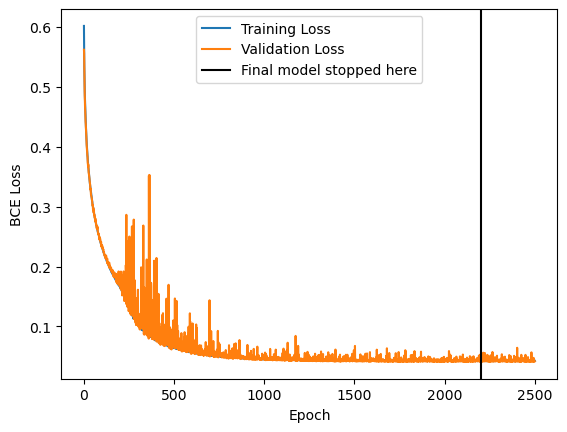

In [30]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

In [31]:


# Save the pretrained classifier model
torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+".pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [32]:
adv = mytools.Adversary(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-5)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=0.999)


## Setup dataloaders

In [33]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)



## Pre-train the adversary leaving classifier weights fixed

In [34]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 6

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 1.623688
Validation loss: 1.622039 

Epoch 2
-------------------------------
Training loss: 1.612610
Validation loss: 1.617346 

Epoch 3
-------------------------------
Training loss: 1.606584
Validation loss: 1.605952 

Epoch 4
-------------------------------
Training loss: 1.602647
Validation loss: 1.602503 

Epoch 5
-------------------------------
Training loss: 1.599820
Validation loss: 1.599979 

Epoch 6
-------------------------------
Training loss: 1.597052
Validation loss: 1.597459 

Epoch 7
-------------------------------
Training loss: 1.595275
Validation loss: 1.595293 

Epoch 8
-------------------------------
Training loss: 1.592988
Validation loss: 1.593408 

Epoch 9
-------------------------------
Training loss: 1.591221
Validation loss: 1.591952 

Epoch 10
-------------------------------
Training loss: 1.590141
Validation loss: 1.591235 

Epoch 11
-------------------------------
Training loss: 1.588955
Validation los

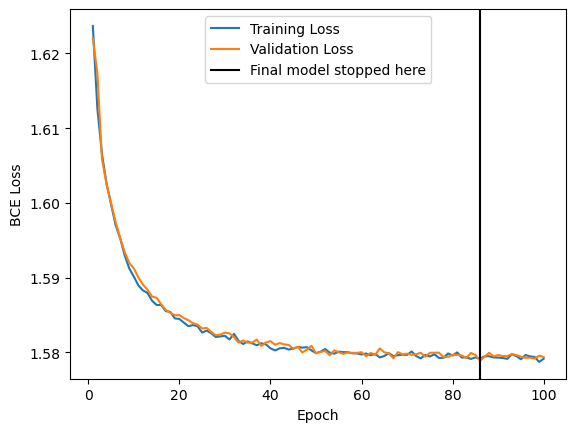

In [35]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [36]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [37]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [38]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-7,betas=(0.5, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-5,betas=(0.5, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

In [39]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 15
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, device)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

final_clas_adv = copy.deepcopy(final_classifier)
final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

Epoch 1
-------------------------------
Classifier validation loss: -157.910490
Adversary validation loss: 1.579516
Classifier training loss: -160.664028
Adversary training loss: 1.609164
Epoch 2
-------------------------------
Classifier validation loss: -164.555158
Adversary validation loss: 1.646136
Classifier training loss: -164.471426
Adversary training loss: 1.646428
Epoch 3
-------------------------------
Classifier validation loss: -164.736617
Adversary validation loss: 1.648266
Classifier training loss: -163.583149
Adversary training loss: 1.637018
Epoch 4
-------------------------------
Classifier validation loss: -163.089116
Adversary validation loss: 1.631859
Classifier training loss: -162.330021
Adversary training loss: 1.624381
Epoch 5
-------------------------------
Classifier validation loss: -162.210982
Adversary validation loss: 1.623050
Classifier training loss: -161.498143
Adversary training loss: 1.616054
Epoch 6
-------------------------------
Classifier validatio

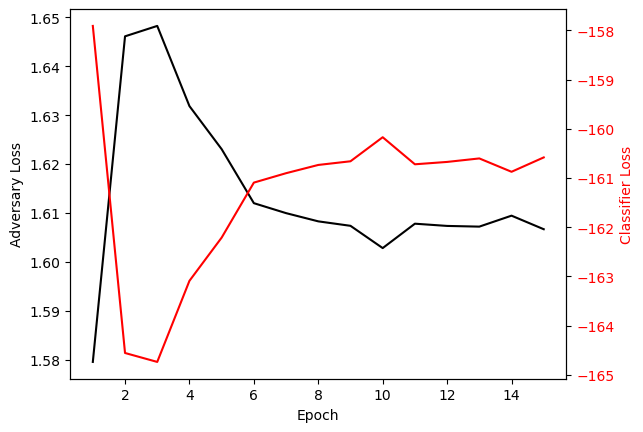

In [40]:
fig, ax1 = plt.subplots()


#ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k-', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

#ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r-', label='Validation Classifier')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



In [41]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+".pt")
torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+".pt")